# Importing Libraries

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier

# Reading the dataset

In [5]:
df=pd.read_csv(r"C:\Users\deepak\Downloads\Customer Churn Data.csv",encoding='latin 1')

# Exploratory Data Analysis

In [6]:
df.head()

,ï»¿year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2015,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,2015,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,2015,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,2015,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,2015,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0


In [7]:
df['year']=df['ï»¿year']

In [8]:
df.drop(columns=['ï»¿year'],inplace = True)

In [9]:
df.head()

,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,year
0,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0,2015
1,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0,2015
2,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0,2015
3,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0,2015
4,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0,2015


In [10]:
df.describe(percentiles=[0.25,0.50,0.75,0.90,1.0])

,customer_id,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,year
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,1972.000000,2000.000000,1965.000000,2000.0
mean,554887.157500,38.69050,99.750000,270.178425,10.198700,30.620780,100.415500,4.482500,3.250507,1.547000,0.133333,2015.0
std,261033.690318,10.20641,39.755386,80.551627,2.785519,9.129165,19.529454,2.487728,0.809084,1.315164,0.340021,0.0
min,100198.000000,18.00000,1.000000,0.000000,0.000000,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,2015.0
25%,328634.750000,32.00000,73.000000,218.212500,8.400000,24.735000,87.000000,3.000000,3.000000,1.000000,0.000000,2015.0
50%,567957.500000,37.00000,99.000000,269.925000,10.200000,30.590000,101.000000,4.000000,3.000000,1.000000,0.000000,2015.0
75%,773280.250000,44.00000,127.000000,324.675000,12.000000,36.797500,114.000000,6.000000,4.000000,2.000000,0.000000,2015.0
90%,911009.600000,52.00000,151.000000,372.915000,13.700000,42.262000,125.000000,8.000000,4.000000,3.000000,1.000000,2015.0
100%,999961.000000,82.00000,243.000000,526.200000,20.000000,59.640000,175.000000,19.000000,6.000000,9.000000,1.000000,2015.0
max,999961.000000,82.00000,243.000000,526.200000,20.000000,59.640000,175.000000,19.000000,6.000000,9.000000,1.000000,2015.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             2000 non-null   int64  
 1   phone_no                2000 non-null   object 
 2   gender                  1976 non-null   object 
 3   age                     2000 non-null   int64  
 4   no_of_days_subscribed   2000 non-null   int64  
 5   multi_screen            2000 non-null   object 
 6   mail_subscribed         2000 non-null   object 
 7   weekly_mins_watched     2000 non-null   float64
 8   minimum_daily_mins      2000 non-null   float64
 9   maximum_daily_mins      2000 non-null   float64
 10  weekly_max_night_mins   2000 non-null   int64  
 11  videos_watched          2000 non-null   int64  
 12  maximum_days_inactive   1972 non-null   float64
 13  customer_support_calls  2000 non-null   int64  
 14  churn                   1965 non-null   

In [12]:
df['gender'].value_counts()

Male      1053
Female     923
Name: gender, dtype: int64

In [13]:
df['churn'].value_counts()

0.0    1703
1.0     262
Name: churn, dtype: int64

In [14]:
df['multi_screen'].value_counts()

no     1802
yes     198
Name: multi_screen, dtype: int64

In [15]:
df['mail_subscribed'].value_counts()

no     1430
yes     570
Name: mail_subscribed, dtype: int64

In [16]:
df['year'].value_counts()

2015    2000
Name: year, dtype: int64

In [17]:
df.shape

(2000, 16)

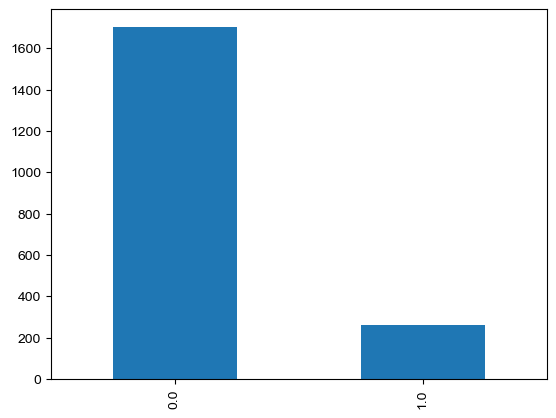

In [18]:
# EDA

df['churn'].value_counts().plot(kind='bar')
sns.set()
sns.set_palette("Set3")

In [19]:
gender_counts=df['gender'].value_counts()

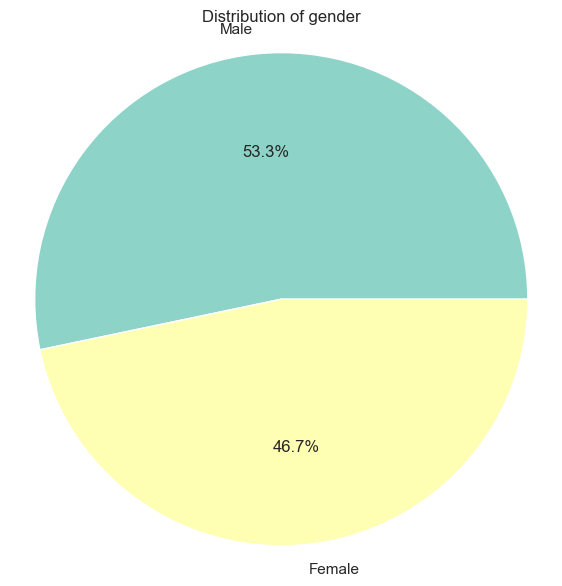

In [20]:
plt.figure(figsize=(7,7))  # Optional: Set the figure size
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Distribution of gender')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.

# Optionally, add Seaborn styling
sns.set()
sns.set_palette("Set3")

plt.show()

In [21]:
correlation=df.corr()

C:\Users\Deepak\AppData\Local\Temp\ipykernel_47092\1332955121.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation=df.corr()


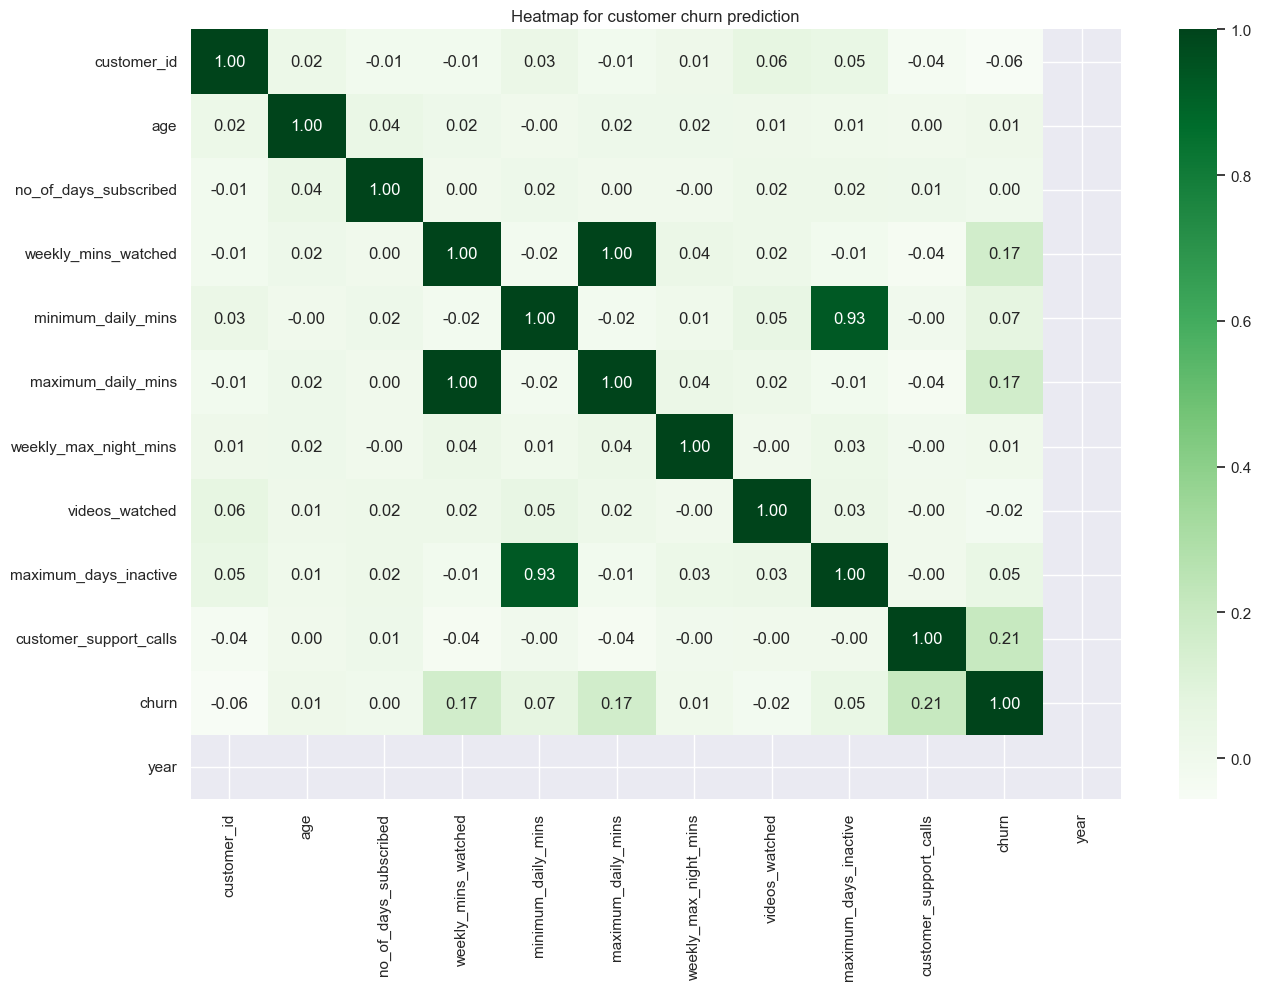

In [22]:
cmap='Greens'
plt.figure(figsize=(15,10))
sns.heatmap(correlation,cmap=cmap,annot=True,fmt=".2f")
plt.title("Heatmap for customer churn prediction")
plt.show()

In [23]:
boxplot=df[['no_of_days_subscribed','weekly_mins_watched','minimum_daily_mins','maximum_daily_mins','weekly_max_night_mins','videos_watched','maximum_days_inactive','customer_support_calls']]

Text(0.5, 1.0, 'Boxplot for Each Variable')

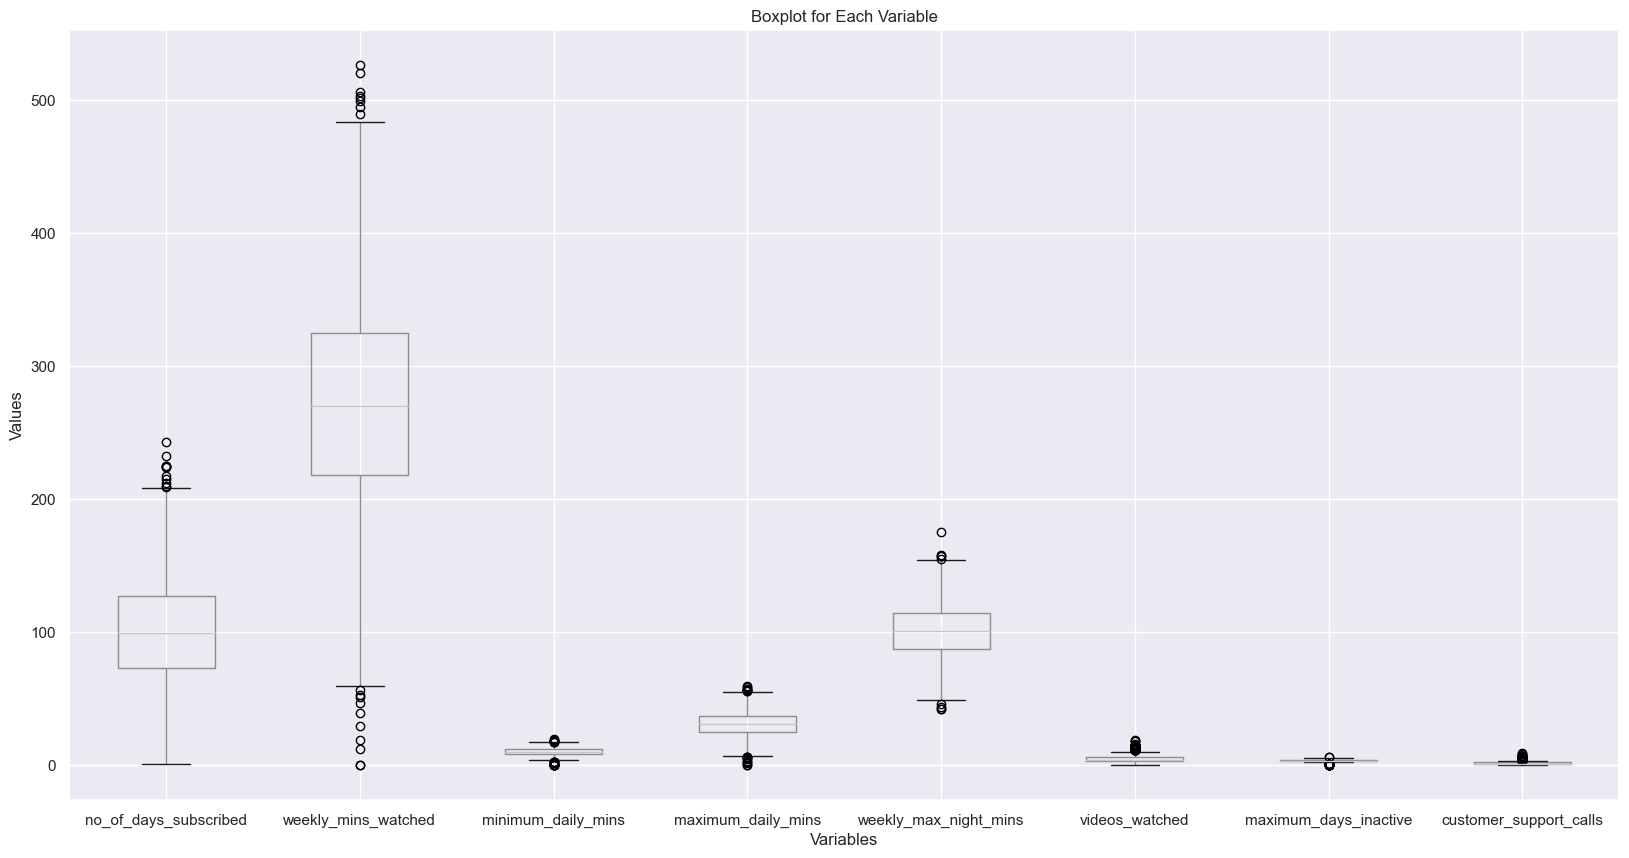

In [24]:
plt.figure(figsize=(20,10))
boxplot.boxplot()


# Adding labels and title
plt.xlabel('Variables')
plt.ylabel('Values')
plt.title('Boxplot for Each Variable')

# Data Preprocessing

In [25]:
df.head()

,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,year
0,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0,2015
1,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0,2015
2,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0,2015
3,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0,2015
4,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0,2015


In [26]:
df=pd.get_dummies(df,columns=['gender'],prefix='gender')

In [27]:
df.drop(columns='gender_Male',inplace=True)

In [28]:
df.head()

,customer_id,phone_no,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,year,gender_Female
0,100198,409-8743,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0,2015,1
1,100643,340-5930,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0,2015,1
2,100756,372-3750,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0,2015,1
3,101595,331-4902,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0,2015,1
4,101653,351-8398,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0,2015,1


In [29]:
df.rename(columns={'gender_Female':'gender'},inplace=True)

In [30]:
df=pd.get_dummies(df,columns=['multi_screen'],prefix='multi_screen')

In [31]:
df.head()

,customer_id,phone_no,age,no_of_days_subscribed,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,year,gender,multi_screen_no,multi_screen_yes
0,100198,409-8743,36,62,no,148.35,12.2,16.81,82,1,4.0,1,0.0,2015,1,1,0
1,100643,340-5930,39,149,no,294.45,7.7,33.37,87,3,3.0,2,0.0,2015,1,1,0
2,100756,372-3750,65,126,no,87.30,11.9,9.89,91,1,4.0,5,1.0,2015,1,1,0
3,101595,331-4902,24,131,yes,321.30,9.5,36.41,102,4,3.0,3,0.0,2015,1,1,0
4,101653,351-8398,40,191,no,243.00,10.9,27.54,83,7,3.0,1,0.0,2015,1,1,0


In [32]:
df.drop(columns='multi_screen_no',inplace=True)

In [33]:
df.rename(columns={'multi_screen_yes':'multi_screen'},inplace=True)

In [34]:
df=pd.get_dummies(df,columns=['mail_subscribed'],prefix='mail_subscribed')

In [35]:
df.drop(columns='mail_subscribed_no',inplace=True)

In [36]:
df.rename(columns={'mail_subscribed_yes':'mail_subscribed'},inplace=True)

In [37]:
df.head()

,customer_id,phone_no,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,year,gender,multi_screen,mail_subscribed
0,100198,409-8743,36,62,148.35,12.2,16.81,82,1,4.0,1,0.0,2015,1,0,0
1,100643,340-5930,39,149,294.45,7.7,33.37,87,3,3.0,2,0.0,2015,1,0,0
2,100756,372-3750,65,126,87.30,11.9,9.89,91,1,4.0,5,1.0,2015,1,0,0
3,101595,331-4902,24,131,321.30,9.5,36.41,102,4,3.0,3,0.0,2015,1,0,1
4,101653,351-8398,40,191,243.00,10.9,27.54,83,7,3.0,1,0.0,2015,1,0,0


In [38]:
columns_to_drop=df[['customer_id','phone_no','year']]


In [39]:
df.drop(columns=columns_to_drop,inplace=True)

In [40]:
df.head()

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn,gender,multi_screen,mail_subscribed
0,36,62,148.35,12.2,16.81,82,1,4.0,1,0.0,1,0,0
1,39,149,294.45,7.7,33.37,87,3,3.0,2,0.0,1,0,0
2,65,126,87.30,11.9,9.89,91,1,4.0,5,1.0,1,0,0
3,24,131,321.30,9.5,36.41,102,4,3.0,3,0.0,1,0,1
4,40,191,243.00,10.9,27.54,83,7,3.0,1,0.0,1,0,0


# Feature Selection

In [41]:
correlation_matrix = df.corr()

# Set the correlation threshold
threshold = 0.8

# Create a mask to identify highly correlated features
mask = (correlation_matrix.abs() > threshold) & (correlation_matrix < 1)

# Get a list of features to drop
features_to_drop = [col for col in mask.columns if any(mask[col])]

# Drop highly correlated features from the DataFrame
df_filtered = df.drop(columns=features_to_drop)

In [42]:

df_filtered


,age,no_of_days_subscribed,weekly_max_night_mins,videos_watched,customer_support_calls,churn,gender,multi_screen,mail_subscribed
0,36,62,82,1,1,0.0,1,0,0
1,39,149,87,3,2,0.0,1,0,0
2,65,126,91,1,5,1.0,1,0,0
3,24,131,102,4,3,0.0,1,0,1
4,40,191,83,7,1,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...
1995,54,75,97,5,2,NaN,1,0,1
1996,45,127,116,3,1,0.0,0,0,0
1997,53,94,110,16,0,0.0,0,0,0
1998,40,94,100,6,3,0.0,0,0,0


In [43]:
df=df_filtered

In [44]:
df

,age,no_of_days_subscribed,weekly_max_night_mins,videos_watched,customer_support_calls,churn,gender,multi_screen,mail_subscribed
0,36,62,82,1,1,0.0,1,0,0
1,39,149,87,3,2,0.0,1,0,0
2,65,126,91,1,5,1.0,1,0,0
3,24,131,102,4,3,0.0,1,0,1
4,40,191,83,7,1,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...
1995,54,75,97,5,2,NaN,1,0,1
1996,45,127,116,3,1,0.0,0,0,0
1997,53,94,110,16,0,0.0,0,0,0
1998,40,94,100,6,3,0.0,0,0,0


# Handling Null values

In [45]:
df.isna().sum()

age                        0
no_of_days_subscribed      0
weekly_max_night_mins      0
videos_watched             0
customer_support_calls     0
churn                     35
gender                     0
multi_screen               0
mail_subscribed            0
dtype: int64

In [46]:
df=df.dropna()

In [47]:
df

,age,no_of_days_subscribed,weekly_max_night_mins,videos_watched,customer_support_calls,churn,gender,multi_screen,mail_subscribed
0,36,62,82,1,1,0.0,1,0,0
1,39,149,87,3,2,0.0,1,0,0
2,65,126,91,1,5,1.0,1,0,0
3,24,131,102,4,3,0.0,1,0,1
4,40,191,83,7,1,0.0,1,0,0
...,...,...,...,...,...,...,...,...,...
1992,42,119,76,3,3,0.0,1,0,1
1996,45,127,116,3,1,0.0,0,0,0
1997,53,94,110,16,0,0.0,0,0,0
1998,40,94,100,6,3,0.0,0,0,0


In [58]:
df.describe(percentiles=[0.25,0.5,0.75,0.90,0.95])

,age,no_of_days_subscribed,weekly_max_night_mins,videos_watched,customer_support_calls,churn,gender,multi_screen,mail_subscribed
count,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000
mean,38.697710,99.750636,100.453944,4.490585,1.544529,0.133333,0.462595,0.099746,0.285496
std,10.196352,39.887889,19.545277,2.488576,1.310958,0.340021,0.498726,0.299737,0.451765
min,18.000000,1.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,72.000000,87.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,99.000000,101.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,44.000000,127.000000,114.000000,6.000000,2.000000,0.000000,1.000000,0.000000,1.000000
90%,52.000000,151.000000,125.000000,8.000000,3.000000,1.000000,1.000000,0.000000,1.000000
95%,59.000000,166.000000,131.800000,9.000000,4.000000,1.000000,1.000000,1.000000,1.000000
max,82.000000,243.000000,175.000000,19.000000,9.000000,1.000000,1.000000,1.000000,1.000000


In [59]:
X=df.drop('churn',axis=1)
y=df['churn']

# Train Test split and Applying SMOTE

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [61]:
y_train_resampled.value_counts()

0.0    1362
1.0    1362
Name: churn, dtype: int64

<Axes: >

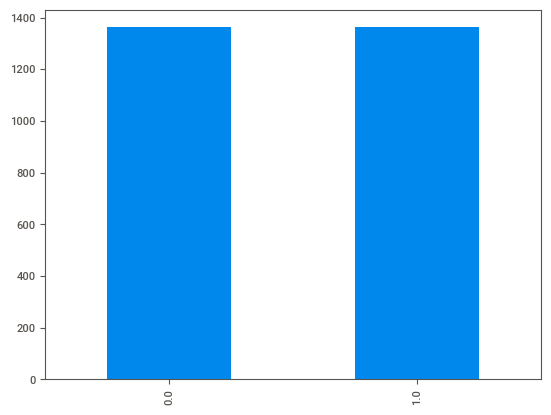

In [62]:
y_train_resampled.value_counts().plot(kind='bar')

# Random Forest Classification

--- Model Evaluation ---
Optimal Threshold: 0.3951
Accuracy: 0.63

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.63      0.75       341
         1.0       0.21      0.65      0.32        52

    accuracy                           0.63       393
   macro avg       0.57      0.64      0.53       393
weighted avg       0.83      0.63      0.69       393



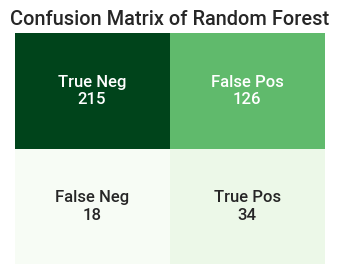

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             precision_recall_curve, f1_score)
# 1. Random Forest with 'balanced' weights to handle class imbalance
rf_classifier = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,              
    min_samples_leaf=5,         
    class_weight='balanced',    
    random_state=42,
    n_jobs=-1
)

# 2. Training the model
rf_classifier.fit(X_train_resampled, y_train_resampled)

# 3. probability scores for the positive class (Churn)
y_prob = rf_classifier.predict_proba(X_test)[:, 1]

# 4. Automate threshold selection using the Precision-Recall curve to maximize F1-Score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
# Avoid division by zero by adding a tiny epsilon
f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

# 5. Applying optimized threshold
y_pred = (y_prob >= best_threshold).astype(int)

# 6. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Optimal Threshold: {best_threshold:.4f}")
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(4, 3)) 

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in conf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(conf_matrix, annot=labels, fmt='', cmap='Greens', cbar=False,
            xticklabels=False, yticklabels=False) 

plt.title('Confusion Matrix of Random Forest')
plt.show()

# XG Boost Classification 

Accuracy: 0.62
Threshold: 0.35

Confusion Matrix:
[[210 131]
 [ 18  34]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.62      0.74       341
         1.0       0.21      0.65      0.31        52

    accuracy                           0.62       393
   macro avg       0.56      0.63      0.53       393
weighted avg       0.83      0.62      0.68       393



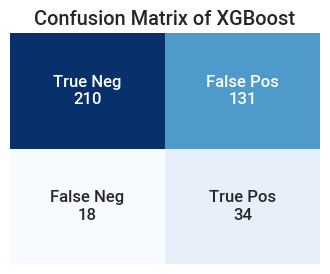

In [100]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Optimized XGBoost
classifier = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Training the model
classifier.fit(X_train_resampled, y_train_resampled)

# Predicting probabilities
y_prob = classifier.predict_proba(X_test)[:, 1]

# Lower threshold to catch more churners
threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Threshold: {threshold}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_rep)

# Plot confusion matrix
plt.figure(figsize=(4, 3)) 

group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in conf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(conf_matrix, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=False, yticklabels=False) 

plt.title('Confusion Matrix of XGBoost')
plt.show()

In [101]:
import sweetviz as sv

my_report = sv.analyze(df)
my_report.show_html()

                                             |                                             | [  0%]   00:00 ->…

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
